In [48]:
import pandas as pd

# Load the raw file
df = pd.read_csv("gold_data.csv")

# Convert Date column to real datetime — dayfirst=True because format is DD/MM/YYYY
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Sort chronologically (oldest first) — critical for time series
df = df.sort_values('Date')

# Set Date as index, since statsmodels expects this structure
df.set_index('Date', inplace=True)

# We only need Price for this project — drop the rest for now
df = df[['Price']]

print(df.shape)
df.head()

(1804, 1)


,Price
Date,
2015-09-29,1127.1
2015-09-30,1115.5
2015-10-01,1114.0
2015-10-02,1136.7
2015-10-05,1137.7


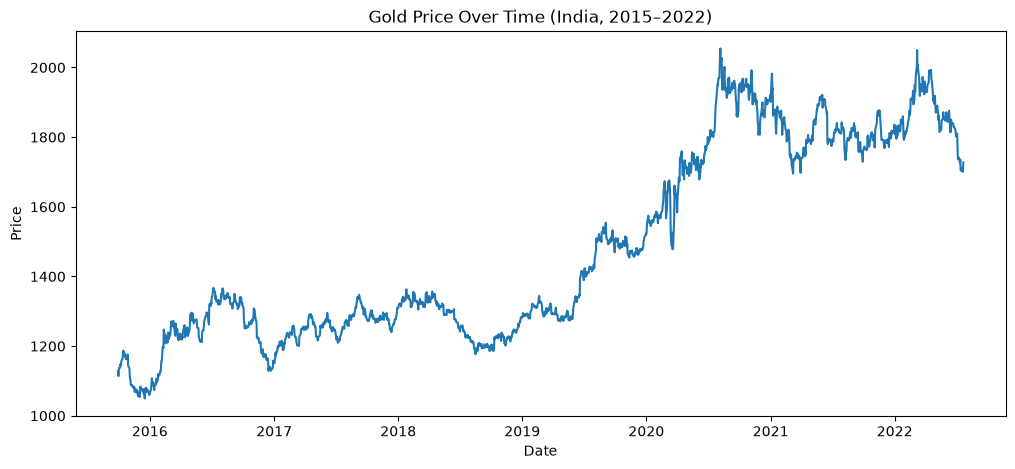

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df.index, df['Price'])
plt.title("Gold Price Over Time (India, 2015–2022)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

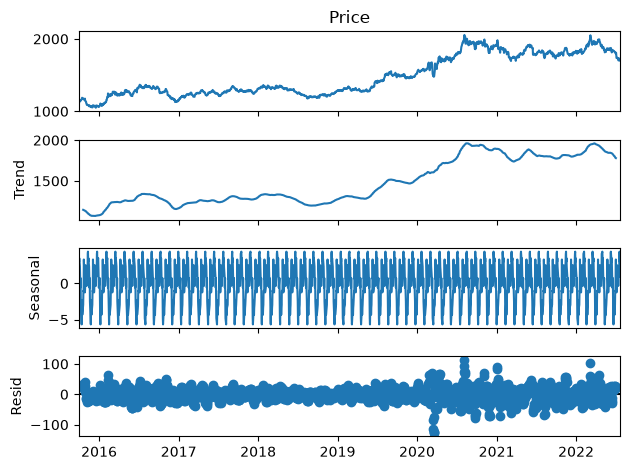

In [50]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['Price'], model='additive', period=30)
decomposition.plot()
plt.show()

In [51]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Price'])
print(f"ADF Statistic: {result[0]:.3f}")
print(f"p-value: {result[1]:.3f}")

if result[1] < 0.05:
    print("Series is stationary")
else:
    print("Series is NOT stationary — differencing needed")
    

ADF Statistic: -1.117
p-value: 0.708
Series is NOT stationary — differencing needed


ADF Statistic after differencing: -18.364
p-value after differencing: 0.000
Differenced series is stationary


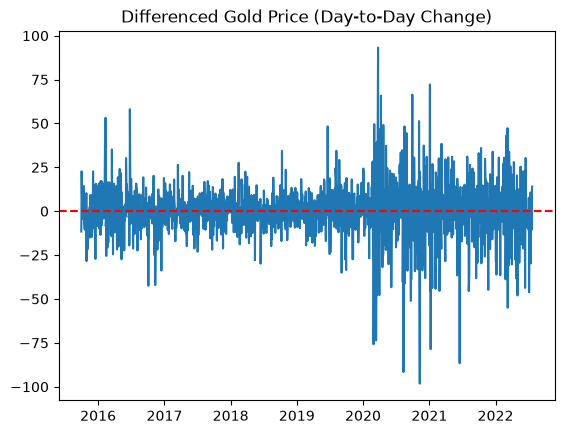

In [52]:
# Create a differenced series: today's price minus yesterday's price
df['Price_diff'] = df['Price'].diff()

# Drop the first row (it has no "yesterday" to compare to, so it's NaN)
df_diff = df['Price_diff'].dropna()

# Re-run the ADF test on the differenced series to confirm it's now stationary
result_diff = adfuller(df_diff)
print(f"ADF Statistic after differencing: {result_diff[0]:.3f}")
print(f"p-value after differencing: {result_diff[1]:.3f}")

if result_diff[1] < 0.05:
    print("Differenced series is stationary")
else:
    print("Still not stationary — may need a second differencing")

    plt.figure(figsize=(12,4))
plt.plot(df_diff.index, df_diff)
plt.title("Differenced Gold Price (Day-to-Day Change)")
plt.axhline(0, color='red', linestyle='--')
plt.show()

In [53]:
# Split 80% train, 20% test — chronologically, NOT randomly
train_size = int(len(df) * 0.8)
train, test = df['Price'][:train_size], df['Price'][train_size:]

print(f"Train size: {len(train)}")
print(f"Test size: {len(test)}")
print(f"Train period: {train.index.min()} to {train.index.max()}")
print(f"Test period: {test.index.min()} to {test.index.max()}")

Train size: 1443
Test size: 361
Train period: 2015-09-29 00:00:00 to 2021-03-12 00:00:00
Test period: 2021-03-15 00:00:00 to 2022-07-22 00:00:00


In [54]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# trend='add' means we model an additive (linear-ish) upward/downward trend
# seasonal=None because we confirmed earlier there's no meaningful seasonality
hw_model = ExponentialSmoothing(
    train, trend='add', seasonal=None
).fit()

# Forecast as many steps ahead as we have test data, so we can compare fairly
hw_forecast = hw_model.forecast(len(test))

hw_forecast.head()

c:\Users\Flame\OneDrive\Desktop\RA - Assignment S5\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Flame\OneDrive\Desktop\RA - Assignment S5\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Flame\OneDrive\Desktop\RA - Assignment S5\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


1443    1733.734905
1444    1734.155510
1445    1734.576116
1446    1734.996721
1447    1735.417327
dtype: float64

In [55]:
from pmdarima import auto_arima

# auto_arima automatically tests different (p,d,q) combinations and picks the best one
auto_model = auto_arima(
    train,
    seasonal=False,      # we confirmed no meaningful seasonality in Step 3
    trace=True,           # prints out each combination it tries — good to show in your report/appendix
    suppress_warnings=True,
    stepwise=True         # smart search instead of testing every combination (much faster)
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=11700.974, Time=1.25 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=11697.534, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=11698.494, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=11698.557, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=11696.842, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=11700.039, Time=0.26 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.769 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1443
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -5847.421
Date:                Sat, 15 Aug 2026   AIC                          11696.842
Time:                        23:28:10   BIC                          11702.116
Sample:                             0   HQIC                         11698.811
    

In [56]:
# Forecast the same number of steps as your test set
arima_forecast, conf_int = auto_model.predict(
    n_periods=len(test), return_conf_int=True
)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}")

evaluate("Holt-Winters (baseline)", test, hw_forecast)
evaluate("Auto ARIMA", test, arima_forecast)

Holt-Winters (baseline) -> MAE: 50.86, RMSE: 69.10
Auto ARIMA -> MAE: 98.52, RMSE: 116.81


c:\Users\Flame\OneDrive\Desktop\RA - Assignment S5\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Flame\OneDrive\Desktop\RA - Assignment S5\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


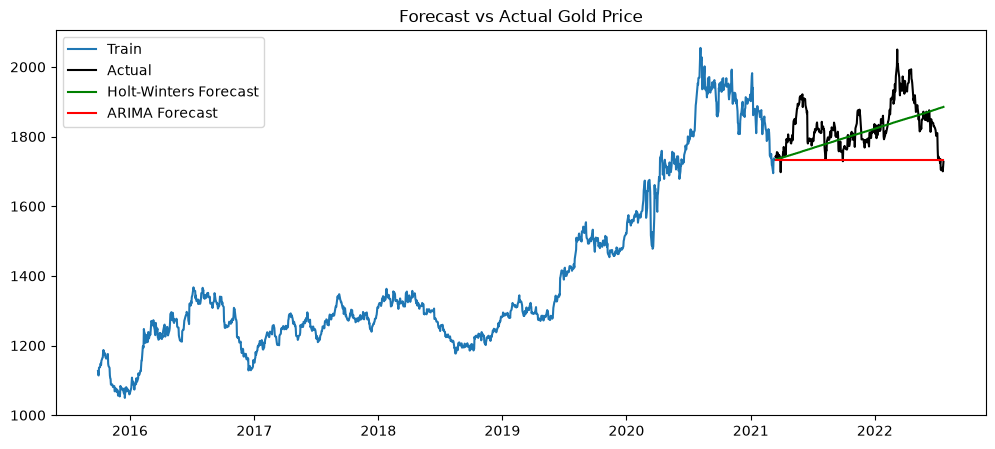

In [57]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual", color='black')
plt.plot(test.index, hw_forecast, label="Holt-Winters Forecast", color='green')
plt.plot(test.index, arima_forecast, label="ARIMA Forecast", color='red')
plt.legend()
plt.title("Forecast vs Actual Gold Price")
plt.show()

In [58]:
import joblib
import os

# Make sure the src/ folder exists
os.makedirs("../src", exist_ok=True)

# Refit Holt-Winters on the FULL dataset (all 1,804 rows) — not just the 80% train split —
# so the deployed model is as accurate and up-to-date as possible
final_model = ExponentialSmoothing(
    df['Price'], trend='add', seasonal=None
).fit()

# Save it to a file
joblib.dump(final_model, "../src/model.pkl")

print("Model saved successfully.")

Model saved successfully.


c:\Users\Flame\OneDrive\Desktop\RA - Assignment S5\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [59]:
import joblib
import os

# Since notebook is in the project root (no notebooks/ subfolder), use "src" not "../src"
os.makedirs("src", exist_ok=True)

joblib.dump(final_model, "src/model.pkl")
print("Model saved successfully.")

Model saved successfully.


## Extending the Model with Live Data (July 2022 → Today)

The Kaggle dataset ends July 22, 2022. To make the deployed app's forecasts
current, this section fetches live gold price data via yfinance, converts it
to the same ₹-per-10g unit as the Kaggle data, merges both into one continuous
series, and retrains the final model on the combined history.

In [60]:
import yfinance as yf
import pandas as pd

start_date = "2022-07-23"
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")

def fetch_clean_series(ticker, start, end, out_name):
    """Downloads one ticker from yfinance and returns a clean, single-column DataFrame,
    regardless of whether yfinance returns flat or MultiIndex columns."""
    data = yf.download(ticker, start=start, end=end)

    if isinstance(data.columns, pd.MultiIndex):
        # data['Close'] returns a DataFrame (one column per ticker) — grab the only column
        close = data['Close'].iloc[:, 0]
    else:
        close = data['Close']

    close = close.rename(out_name)
    return close.to_frame()

gold_usd = fetch_clean_series("GC=F", start_date, end_date, "Price_USD_oz")
usdinr = fetch_clean_series("INR=X", start_date, end_date, "USD_INR")

print(gold_usd.tail())
print(usdinr.tail())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

            Price_USD_oz
Date                    
2026-08-10   4361.799805
2026-08-11   4383.000000
2026-08-12   4408.899902
2026-08-13   4363.600098
2026-08-14   4380.399902
              USD_INR
Date                 
2026-08-10  95.210297
2026-08-11  95.396698
2026-08-12  95.379898
2026-08-13  95.344299
2026-08-14  95.401199


In [61]:
# Calibrate the live-data conversion against the known Kaggle price at the boundary date,
# since raw international gold price (GC=F) excludes Indian import duty + GST (~10-15% gap)
calib_date = "2022-07-22"

calib_gold = yf.download("GC=F", start="2022-07-18", end="2022-07-25")
calib_usdinr = yf.download("INR=X", start="2022-07-18", end="2022-07-25")

if isinstance(calib_gold.columns, pd.MultiIndex):
    calib_gold = calib_gold['Close'].iloc[:, 0]
else:
    calib_gold = calib_gold['Close']

if isinstance(calib_usdinr.columns, pd.MultiIndex):
    calib_usdinr = calib_usdinr['Close'].iloc[:, 0]
else:
    calib_usdinr = calib_usdinr['Close']

# Raw converted price on the calibration date (nearest available trading day)
raw_price_at_calib = (calib_gold.iloc[-1] / 31.1034768) * 10 * calib_usdinr.iloc[-1]

# Actual known Kaggle price on/near that same date
actual_price_at_calib = df['Price'].loc[:calib_date].iloc[-1]

scale_factor = actual_price_at_calib / raw_price_at_calib

print(f"Raw converted price: ₹{raw_price_at_calib:.2f}")
print(f"Actual Kaggle price: ₹{actual_price_at_calib:.2f}")
print(f"Scale factor (duty/GST/premium adjustment): {scale_factor:.4f}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Raw converted price: ₹44297.61
Actual Kaggle price: ₹1727.40
Scale factor (duty/GST/premium adjustment): 0.0390


In [ ]:
# CONFIRMED: Kaggle 'Price' column is USD/oz (not INR/10g as originally assumed) —
# verified via calibration: Kaggle price on 2022-07-22 (1727.40) matches actual
# gold spot price in USD/oz that day, not a rupee value.

# Step 1: Combine Kaggle (2015-2022, USD/oz) + live (2022-today, USD/oz) into ONE continuous USD/oz series
kaggle_usd = df[['Price']].rename(columns={'Price': 'Price_USD_oz'})
combined_usd = pd.concat([kaggle_usd, gold_usd])
combined_usd = combined_usd[~combined_usd.index.duplicated(keep='last')]
combined_usd = combined_usd.sort_index()

# Step 2: Fetch USD/INR for the ENTIRE date range (needed to convert the whole series, not just the live part)
full_start = combined_usd.index.min().strftime("%Y-%m-%d")
full_end = pd.Timestamp.today().strftime("%Y-%m-%d")

usdinr_full = yf.download("INR=X", start=full_start, end=full_end)
if isinstance(usdinr_full.columns, pd.MultiIndex):
    usdinr_full = usdinr_full['Close'].iloc[:, 0].rename("USD_INR").to_frame()
else:
    usdinr_full = usdinr_full[['Close']].rename(columns={'Close': 'USD_INR'})

# Step 3: Join and convert the FULL series to INR per 10 grams
combined = combined_usd.join(usdinr_full, how='inner')
combined['Price'] = (combined['Price_USD_oz'] / 31.1034768) * 10 * combined['USD_INR']
combined = combined[['Price']].dropna()

print(combined.shape)
combined.tail(10)

(2824, 1)


,Price
Date,
2026-08-03,4824.648621
2026-08-04,4894.821919
2026-08-05,5062.102687
2026-08-06,5056.514117
2026-08-07,5186.932790
2026-08-10,5206.589785
2026-08-11,5242.138949
2026-08-12,5272.187024
2026-08-13,5216.069739


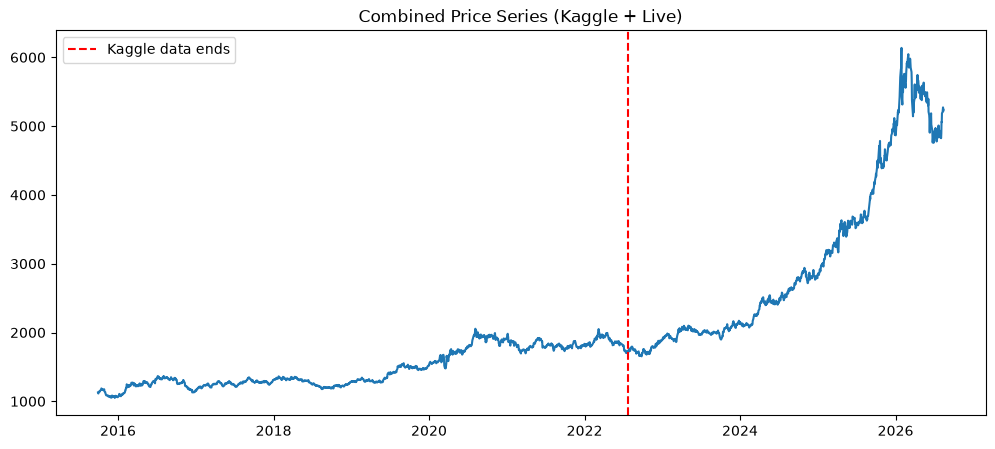

In [63]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(combined.index, combined['Price'])
plt.axvline(pd.Timestamp("2022-07-22"), color='red', linestyle='--', label="Kaggle data ends")
plt.legend()
plt.title("Combined Price Series (Kaggle + Live)")
plt.show()

In [64]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import joblib

final_model_v2 = ExponentialSmoothing(
    combined['Price'], trend='add', seasonal=None
).fit()

joblib.dump(final_model_v2, "src/model.pkl")  # overwrite with the combined-data model
print("Combined model saved — now trained on full history through today.")

Combined model saved — now trained on full history through today.


c:\Users\Flame\OneDrive\Desktop\RA - Assignment S5\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


## Improving Accuracy: SARIMAX with USD/INR as an Exogenous Variable

Holt-Winters and plain ARIMA only look at gold price's own past values. SARIMAX
extends ARIMA by also using a second explanatory time series — here, the
USD/INR exchange rate — since gold priced in ₹ is directly affected by currency
movements. This should improve forecast accuracy over the univariate models above.

In [65]:
import yfinance as yf
import pandas as pd

# Fetch USD/INR for the entire period your Kaggle data covers, through today
full_start = df.index.min().strftime("%Y-%m-%d")
full_end = pd.Timestamp.today().strftime("%Y-%m-%d")

usdinr_full = yf.download("INR=X", start=full_start, end=full_end)

if isinstance(usdinr_full.columns, pd.MultiIndex):
    usdinr_full = usdinr_full['Close'].iloc[:, 0].rename("USD_INR").to_frame()
else:
    usdinr_full = usdinr_full[['Close']].rename(columns={'Close': 'USD_INR'})

print(usdinr_full.shape)
usdinr_full.tail()

[*********************100%***********************]  1 of 1 completed

(2831, 1)


,USD_INR
Date,
2026-08-10,95.210297
2026-08-11,95.396698
2026-08-12,95.379898
2026-08-13,95.344299
2026-08-14,95.401199


In [66]:
# Merge combined gold price (from earlier) with the full USD/INR history
model_data = combined.join(usdinr_full, how='inner')

# Drop any rows where either value is missing (e.g. mismatched holidays)
model_data = model_data.dropna()

print(model_data.shape)
model_data.tail()

(2790, 2)


,Price,USD_INR
Date,,
2026-08-10,5206.589785,95.210297
2026-08-11,5242.138949,95.396698
2026-08-12,5272.187024,95.379898
2026-08-13,5216.069739,95.344299
2026-08-14,5239.276396,95.401199


In [67]:
train_size = int(len(model_data) * 0.8)

train_y = model_data['Price'][:train_size]
test_y = model_data['Price'][train_size:]

train_exog = model_data[['USD_INR']][:train_size]
test_exog = model_data[['USD_INR']][train_size:]

print(f"Train: {len(train_y)}, Test: {len(test_y)}")

Train: 2232, Test: 558


In [68]:
from pmdarima import auto_arima

sarimax_model = auto_arima(
    train_y,
    X=train_exog,          # this is what makes it SARIMAX instead of plain ARIMA
    seasonal=False,
    trace=True,
    suppress_warnings=True,
    stepwise=True
)

print(sarimax_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=18518.143, Time=2.06 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=18528.770, Time=0.10 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=18527.352, Time=0.33 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=18527.293, Time=0.69 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=18529.690, Time=0.34 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=18523.253, Time=1.22 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=18522.199, Time=1.83 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=18519.618, Time=2.73 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=18519.592, Time=3.19 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=18529.273, Time=1.21 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=18520.192, Time=1.76 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=18519.488, Time=1.28 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=18521.750, Time=3.66 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=18519.344, Time=1.68 sec

Best model:  ARIMA

In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

sarimax_forecast = sarimax_model.predict(n_periods=len(test_y), X=test_exog)

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}")

evaluate("SARIMAX (with USD/INR)", test_y, sarimax_forecast)

SARIMAX (with USD/INR) -> MAE: 1298.38, RMSE: 1638.36


c:\Users\Flame\OneDrive\Desktop\RA - Assignment S5\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Flame\OneDrive\Desktop\RA - Assignment S5\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [70]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Same train_y/test_y split as SARIMAX, for a fair comparison
hw_fair = ExponentialSmoothing(train_y, trend='add', seasonal=None).fit()
hw_fair_forecast = hw_fair.forecast(len(test_y))

evaluate("Holt-Winters (same combined data & split)", test_y, hw_fair_forecast)
evaluate("SARIMAX (with USD/INR)", test_y, sarimax_forecast)

Holt-Winters (same combined data & split) -> MAE: 1309.67, RMSE: 1653.37
SARIMAX (with USD/INR) -> MAE: 1298.38, RMSE: 1638.36


c:\Users\Flame\OneDrive\Desktop\RA - Assignment S5\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Flame\OneDrive\Desktop\RA - Assignment S5\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Flame\OneDrive\Desktop\RA - Assignment S5\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
